# Sanity Check (YOLO Model)

This notebook contains a quick sanity check to ensure the model is able to train as expected using the implementation. It is using a very small subset of the dataset to run and identify issues quickly.

In [6]:
import sys

import matplotlib.pyplot as plt

In [8]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import detect
import dataset

In [ ]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(detect)
importlib.reload(dataset);

We start by training the YOLO model with the custom keypoints head on a very small subset of the complete dataset. 

In [4]:
model = detect.CustomHeadedYolo(path="../nets")

# Train the model for some epochs in the dummy dataset.
detect.train_epochs_in(500, None, None, model, testing=True)

epoch 0; train: loss 18.767261505126953; val: loss 13.38736629486084
epoch 1; train: loss 10.892189025878906; val: loss 12.589446067810059
epoch 2; train: loss 9.319416046142578; val: loss 11.714838981628418
epoch 3; train: loss 8.66102409362793; val: loss 10.975164413452148
epoch 4; train: loss 8.304985046386719; val: loss 10.202386856079102
epoch 5; train: loss 8.099832534790039; val: loss 9.65200424194336
epoch 6; train: loss 7.952144145965576; val: loss 9.204668998718262
epoch 7; train: loss 7.8410420417785645; val: loss 8.815667152404785
epoch 8; train: loss 7.84803581237793; val: loss 8.497397422790527
epoch 9; train: loss 7.65478515625; val: loss 8.235016822814941
epoch 10; train: loss 7.573592662811279; val: loss 8.025679588317871
epoch 11; train: loss 7.483428001403809; val: loss 7.863986492156982
epoch 12; train: loss 7.400334358215332; val: loss 7.73679256439209
epoch 13; train: loss 7.31843900680542; val: loss 7.6195783615112305
epoch 14; train: loss 7.232636451721191; val:

As can be seen above, the basic implementation of the training look works, decreasing the loss from 13.39 down to 3.22. Obviously this is just on a very small subset of the data so we expect significant overfitting to take place here. Below we look at some examples of applying the learned detector on some example images.

In [49]:
# Load one example sample from the dataset.
data = dataset.YoloDataset("../data/yolo/train")
img, ann = data[5]
# Try to run the learned detector on the sample.
detector = detect.CustomPoseDetector(model)
mean, cov = detector.detect_simple(img.unsqueeze(0).to("cuda"))[0]
# Try also to use the baseline YOLO model.
detector2 = detect.PoseDetector(path="../nets", compile=False)
mean2, cov2 = detector2.detect_simple(img.unsqueeze(0))[0]

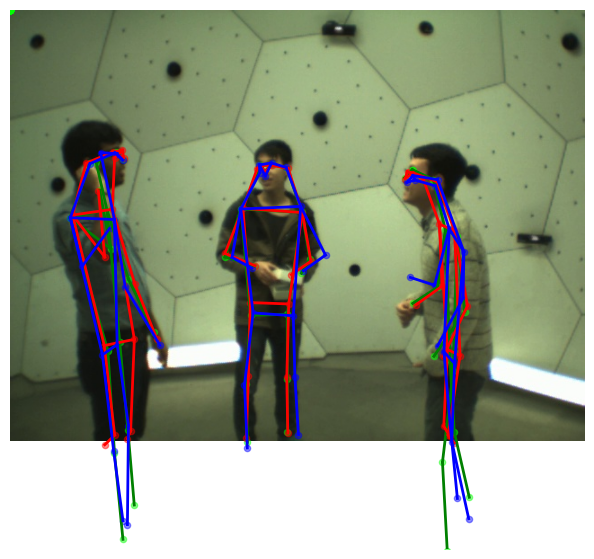

In [50]:
# Visualize the results.
plt.figure(figsize=(8, 7))
for kp in ann:
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='green', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#00ff0070')
for kp in mean2.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='red', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#ff000070')
for kp in mean.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='blue', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#0000ff70')
plt.imshow(img.permute(1, 2, 0))
plt.ylim(600, 0)
plt.axis("off")
plt.show()

As can be seen above, the predictions are not perfect, but they are also not terrible. Note that the red one is the native YOLO prediction, the blue one is the custom heads predictions, and the green skeletons are the ground truth.